In [1]:
# Asegura dependencias de visualizacion en el cluster
import importlib, subprocess, sys
for pkg in ['seaborn']:
    try: importlib.import_module(pkg)
    except ImportError: subprocess.run([sys.executable,'-m','pip','install','-q',pkg])
print('deps OK')

deps OK


<div style="text-align:center;">

# Actividad 3 | Aprendizaje Supervisado y No Supervisado

**Tecnológico de Monterrey**
**Maestría en Inteligencia Artificial Aplicada**
**TC4034 — Análisis de Grandes Volúmenes de Datos**

**Alumno:** Oscar Alberto Ramírez Anaya
**Matrícula:** A01795438
**Correo:** A01795438@tec.mx
**Modalidad:** Individual
**Fecha:** Mayo 2026

</div>

---

> **Nota de cómputo.** Este cuaderno se ejecuta sobre **Apache Spark (PySpark)** en modo local
> (`local[*]`). El mismo pipeline está diseñado para escalar sin cambios a un clúster **GCP Dataproc**
> leyendo la base global completa desde Cloud Storage (`gs://…`); los scripts de aprovisionamiento de
> Dataproc se incluyen en `scripts/` del repositorio. La base de datos global **D** y su
> particionamiento provienen del proyecto de la Evidencia 1 (Módulo 3), del cual el autor fue
> coautor; aquí se reutiliza ese pipeline para construir la muestra **M** y entrenar los modelos.

## 1. Introducción teórica

El **aprendizaje automático** (Machine Learning) se divide, según la naturaleza de la supervisión
disponible en los datos, en dos grandes familias que se aplican en esta actividad.

### 1.1 Aprendizaje supervisado
En el aprendizaje **supervisado** cada instancia de entrenamiento está acompañada de una **etiqueta**
(variable objetivo) conocida. El algoritmo aprende una función que mapea las características de entrada
*X* a la salida *y*, de modo que pueda predecir la etiqueta de instancias nuevas. Si la salida es
categórica el problema es de **clasificación**; si es continua, de **regresión**. Algoritmos
representativos en la literatura: árboles de decisión, *Random Forest*, *Gradient Boosting* (GBT),
máquinas de soporte vectorial (SVM), regresión logística, *Naive Bayes* y perceptrón multicapa (MLP).

### 1.2 Aprendizaje no supervisado
En el aprendizaje **no supervisado** los datos **no** tienen etiqueta. El objetivo es descubrir
estructura latente: agrupar instancias similares (**clustering**), reducir dimensionalidad o estimar
densidades. Algoritmos representativos: *K-Means*, mezclas gaussianas (*Gaussian Mixture*), clustering
jerárquico, DBSCAN y *Power Iteration Clustering* (PIC).

### 1.3 Algoritmos disponibles en PySpark MLlib
La biblioteca distribuida `pyspark.ml` ofrece implementaciones que operan sobre `DataFrame`s y escalan
horizontalmente:

| Tipo | Algoritmos en `pyspark.ml` |
|---|---|
| Clasificación (supervisado) | `LogisticRegression`, `DecisionTreeClassifier`, **`RandomForestClassifier`**, `GBTClassifier`, `MultilayerPerceptronClassifier`, `NaiveBayes`, `LinearSVC` |
| Regresión (supervisado) | `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`, `GBTRegressor`, `GeneralizedLinearRegression` |
| Clustering (no supervisado) | **`KMeans`**, `BisectingKMeans`, `GaussianMixture`, `PowerIterationClustering`, `LDA` |

En esta actividad se aplican **`RandomForestClassifier`** (supervisado) y **`KMeans`** (no supervisado).

### 1.4 Encuadre profesional
Desde mi rol como **arquitecto de datos a escala en GCP** (microservicios cloud-native), el valor de
estos algoritmos no está solo en el modelo sino en el **pipeline de datos** que los alimenta: ingestión
a gran volumen, particionamiento por variables de caracterización, y **muestreo estratificado** que
reduce el costo de cómputo sin sesgar la población. Spark/Dataproc permiten ejecutar exactamente el
mismo código sobre millones de registros; el muestreo contenido que aplico aquí es la misma técnica que
en producción se usa para prototipar modelos antes de escalarlos.

## 2. Selección de los datos

**Base global D = NYC TLC Yellow Taxi Trip Records 2024** (formato Parquet), publicada por la *New York
City Taxi & Limousine Commission*. Para mantener tiempos de procesamiento contenidos se cargan 3 meses
representativos (enero–marzo 2024); el pipeline es idéntico al de la Evidencia 1 sobre los 12 meses.

A partir de **D** se construye la muestra **M** reutilizando el particionamiento del Módulo 3:
tres **variables de caracterización** (`tipo_dia` × `zona_origen` × `tipo_pago`) que generan 12
estratos disjuntos, y un **muestreo estratificado proporcional** (`DataFrame.sampleBy`) que preserva
las proporciones de la población.

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
# En Dataproc la sesion se conecta al cluster (YARN); no se usa master local.
spark = SparkSession.builder.appName('Actividad3_Dataproc_A01795438').getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('Spark', spark.version, '| modo:', spark.sparkContext.master)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/01 01:49:13 INFO SparkEnv: Registering MapOutputTracker
26/06/01 01:49:13 INFO SparkEnv: Registering BlockManagerMaster
26/06/01 01:49:13 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/06/01 01:49:14 INFO SparkEnv: Registering OutputCommitCoordinator


Spark 3.5.3 | modo: yarn


In [3]:
from functools import reduce
from pyspark.sql import DataFrame
BASE = 'gs://<GCS_BUCKET>/yellow_2024/'

# Cargador robusto: cada mes con su esquema inferido + cast a tipos canonicos,
# para resolver la heterogeneidad INT64/DOUBLE entre archivos.
def cargar_mes(path):
    d = spark.read.parquet(path)
    return d.select(
        F.col('tpep_pickup_datetime').cast('timestamp').alias('tpep_pickup_datetime'),
        F.col('tpep_dropoff_datetime').cast('timestamp').alias('tpep_dropoff_datetime'),
        F.col('passenger_count').cast('double').alias('passenger_count'),
        F.col('trip_distance').cast('double').alias('trip_distance'),
        F.col('RatecodeID').cast('double').alias('RatecodeID'),
        F.col('PULocationID').cast('long').alias('PULocationID'),
        F.col('payment_type').cast('long').alias('payment_type'),
        F.col('fare_amount').cast('double').alias('fare_amount'),
        F.col('extra').cast('double').alias('extra'),
        F.col('mta_tax').cast('double').alias('mta_tax'),
        F.col('tip_amount').cast('double').alias('tip_amount'),
        F.col('tolls_amount').cast('double').alias('tolls_amount'),
        F.col('improvement_surcharge').cast('double').alias('improvement_surcharge'),
        F.col('total_amount').cast('double').alias('total_amount'),
        F.col('congestion_surcharge').cast('double').alias('congestion_surcharge'),
    )

meses = [f'{BASE}yellow_tripdata_2024-{m:02d}.parquet' for m in range(1, 13)]
df = reduce(DataFrame.unionByName, [cargar_mes(p) for p in meses]).cache()
TOTAL = df.count()
print(f'Base global D (Dataproc, 12 meses): {TOTAL:,} registros | {len(df.columns)} columnas')

Base global D (Dataproc, 12 meses): 41,169,720 registros | 15 columnas


In [4]:
# Panorama: nulos por columna (top 8)
print("Tasa de nulos por columna (top 8):")
exprs = [F.round(F.mean(F.col(c).isNull().cast("double")), 4).alias(c) for c in df.columns]
nul = df.select(exprs).toPandas().T.rename(columns={0: "tasa_nulos"})
print(nul.sort_values("tasa_nulos", ascending=False).head(8).to_string())

Tasa de nulos por columna (top 8):


26/06/01 01:50:15 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


                       tasa_nulos
passenger_count            0.0994
RatecodeID                 0.0994
congestion_surcharge       0.0994
tpep_dropoff_datetime      0.0000
trip_distance              0.0000
PULocationID               0.0000
tpep_pickup_datetime       0.0000
payment_type               0.0000


### 2.1 Capa Silver: filtros de calidad antes de particionar
Se aplican los filtros de calidad de la Evidencia 1 para que el particionamiento opere sobre registros
válidos (sin outliers conocidos).

In [5]:
df_silver = (df
    .filter(F.col("fare_amount") > 0)
    .filter(F.col("trip_distance") > 0)
    .filter(F.col("trip_distance") < 200)
    .filter(F.col("tpep_pickup_datetime") < F.col("tpep_dropoff_datetime"))
    .filter((F.col("RatecodeID").isNull()) | (F.col("RatecodeID") != 99))
    .filter(F.col("PULocationID").isNotNull())
    .filter(F.col("payment_type").isNotNull())
    .filter(F.year("tpep_pickup_datetime") == 2024))
N_SILVER = df_silver.count()
print(f"Registros tras capa Silver: {N_SILVER:,}  ({(1-N_SILVER/TOTAL)*100:.2f}% descartado)")

Registros tras capa Silver: 39,263,800  (4.63% descartado)


### 2.2 Variables de caracterización y particion_id
Se construyen las 3 variables derivadas de partición (`tipo_dia`, `zona_origen`, `tipo_pago`) y la clave
combinada `particion_id`. Esta es la misma lógica del Módulo 3.

In [6]:
# Variable A: tipo de dia (dayofweek: 1=Dom, ..., 7=Sab)
df_part = df_silver.withColumn("tipo_dia",
    F.when(F.dayofweek("tpep_pickup_datetime").isin([1, 7]), "Finde").otherwise("Laborable"))

# Variable B: zona de origen (IDs oficiales TLC)
manhattan_ids = [4,12,13,24,41,42,43,45,48,50,68,74,75,79,87,88,90,100,103,104,105,107,113,114,116,
                 120,125,127,128,137,140,141,142,143,144,148,151,152,153,158,161,162,163,164,166,170,
                 186,194,202,209,211,224,229,230,231,232,233,234,236,237,238,239,243,244,246,249,261,262,263]
aeropuerto_ids = [1, 132, 138]   # Newark, JFK, LaGuardia
df_part = df_part.withColumn("zona_origen",
    F.when(F.col("PULocationID").isin(aeropuerto_ids), "Aeropuerto")
     .when(F.col("PULocationID").isin(manhattan_ids), "Manhattan")
     .otherwise("Otros"))

# Variable C: metodo de pago
df_part = df_part.withColumn("tipo_pago",
    F.when(F.col("payment_type") == 1, "Tarjeta").otherwise("NoTarjeta"))

# Clave de particion
df_part = df_part.withColumn("particion_id",
    F.concat_ws("|", F.col("tipo_dia"), F.col("zona_origen"), F.col("tipo_pago")))
df_part.cache()

df_part.select("tipo_dia","zona_origen","tipo_pago","particion_id").show(6, truncate=False)
print("Particiones (estratos) encontradas:", df_part.select("particion_id").distinct().count())

+---------+-----------+---------+-----------------------------+
|tipo_dia |zona_origen|tipo_pago|particion_id                 |
+---------+-----------+---------+-----------------------------+
|Laborable|Manhattan  |NoTarjeta|Laborable|Manhattan|NoTarjeta|
|Laborable|Manhattan  |Tarjeta  |Laborable|Manhattan|Tarjeta  |
|Laborable|Manhattan  |Tarjeta  |Laborable|Manhattan|Tarjeta  |
|Laborable|Manhattan  |Tarjeta  |Laborable|Manhattan|Tarjeta  |
|Laborable|Manhattan  |Tarjeta  |Laborable|Manhattan|Tarjeta  |
|Laborable|Manhattan  |Tarjeta  |Laborable|Manhattan|Tarjeta  |
+---------+-----------+---------+-----------------------------+
only showing top 6 rows



Particiones (estratos) encontradas: 12


### 2.3 Muestreo estratificado proporcional → muestra M
Se aplica `DataFrame.sampleBy` con fracciones por estrato calculadas de forma **proporcional** al tamaño
de cada partición, de modo que `n_i = n · |P_i|/|D|`. Objetivo: **M ≈ 50,000** registros (muestra
contenida). Esta es la técnica de muestreo propuesta en el Módulo 3 (paso 4).

In [7]:
N_OBJETIVO = 50_000

# Conteo por estrato y fraccion proporcional (n_i/|P_i| = n/|D|, acotada a [0,1])
conteos = {r["particion_id"]: r["count"]
           for r in df_part.groupBy("particion_id").count().collect()}
fracciones = {pid: max(0.0, min(1.0, N_OBJETIVO / N_SILVER)) for pid in conteos}

muestra_M = df_part.sampleBy("particion_id", fractions=fracciones, seed=42)
muestra_M.cache()
N_M = muestra_M.count()
print(f"Muestra M: {N_M:,} registros  (~{100*N_M/N_SILVER:.3f}% de D)")

Muestra M: 49,928 registros  (~0.127% de D)


### 2.4 Validación: M reproduce las proporciones de la población
Se compara la distribución por estrato de **M** contra la de **D** (capa Silver). Una desviación máxima
pequeña confirma que el muestreo estratificado preservó la estructura poblacional.

In [8]:
import pandas as pd
pob = (df_part.groupBy("particion_id").count()
       .withColumn("P_poblacion", F.col("count")/N_SILVER)
       .toPandas().rename(columns={"count":"n_D"}))
mue = (muestra_M.groupBy("particion_id").count()
       .withColumn("P_muestra", F.col("count")/N_M)
       .toPandas().rename(columns={"count":"n_M"}))
val = pob.merge(mue, on="particion_id", how="left").fillna(0)
val["abs_err"] = (val["P_poblacion"] - val["P_muestra"]).abs()
val = val.sort_values("P_poblacion", ascending=False).reset_index(drop=True)
val[["P_poblacion","P_muestra","abs_err"]] = val[["P_poblacion","P_muestra","abs_err"]].round(4)
print(val[["particion_id","n_D","n_M","P_poblacion","P_muestra","abs_err"]].to_string(index=False))
print(f"\nDesviación máxima |P_D - P_M|: {val['abs_err'].max():.4f}")

                  particion_id      n_D   n_M  P_poblacion  P_muestra  abs_err
   Laborable|Manhattan|Tarjeta 19598574 24860       0.4992     0.4979   0.0012
       Finde|Manhattan|Tarjeta  7245038  9222       0.1845     0.1847   0.0002
 Laborable|Manhattan|NoTarjeta  5728077  7207       0.1459     0.1443   0.0015
     Finde|Manhattan|NoTarjeta  2561052  3365       0.0652     0.0674   0.0022
  Laborable|Aeropuerto|Tarjeta  1812249  2298       0.0462     0.0460   0.0001
      Finde|Aeropuerto|Tarjeta   673092   883       0.0171     0.0177   0.0005
Laborable|Aeropuerto|NoTarjeta   473365   616       0.0121     0.0123   0.0003
     Laborable|Otros|NoTarjeta   329857   404       0.0084     0.0081   0.0003
       Laborable|Otros|Tarjeta   290836   352       0.0074     0.0071   0.0004
         Finde|Otros|NoTarjeta   248146   344       0.0063     0.0069   0.0006
    Finde|Aeropuerto|NoTarjeta   175537   209       0.0045     0.0042   0.0003
           Finde|Otros|Tarjeta   127977   168       

## 3. Preparación de los datos

Sobre la muestra **M** se aplican las correcciones finales antes del modelado:
1. **Valores nulos** en columnas relevantes → imputación/descartado.
2. **Outliers** residuales (la capa Silver ya filtró los principales; se refuerza un tope superior en
   importes y duración).
3. **Transformación de tipos** y **feature engineering**: `trip_duration_min`, `pickup_hour`,
   `dia_semana`.

In [9]:
M = (muestra_M
     # Feature engineering
     .withColumn("trip_duration_min",
                 (F.col("tpep_dropoff_datetime").cast("long") -
                  F.col("tpep_pickup_datetime").cast("long")) / 60.0)
     .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
     .withColumn("dia_semana", F.dayofweek("tpep_pickup_datetime")))

# Imputacion de nulos numericos relevantes
M = M.fillna({"passenger_count": 1, "congestion_surcharge": 0.0,
              "extra": 0.0, "mta_tax": 0.0, "tolls_amount": 0.0,
              "improvement_surcharge": 0.0})

# Refuerzo anti-outliers (topes razonables para viajes urbanos)
M = (M.filter((F.col("trip_duration_min") > 0) & (F.col("trip_duration_min") < 180))
       .filter(F.col("fare_amount") < 500)
       .filter((F.col("passenger_count") >= 1) & (F.col("passenger_count") <= 6)))

N_M2 = M.count()
M.cache()
print(f"Muestra M preprocesada: {N_M2:,} registros")
M.select("trip_distance","fare_amount","trip_duration_min","pickup_hour",
         "passenger_count","zona_origen","tipo_dia","tipo_pago").describe().show()

Muestra M preprocesada: 49,415 registros


+-------+------------------+------------------+-------------------+------------------+------------------+-----------+---------+---------+
|summary|     trip_distance|       fare_amount|  trip_duration_min|       pickup_hour|   passenger_count|zona_origen| tipo_dia|tipo_pago|
+-------+------------------+------------------+-------------------+------------------+------------------+-----------+---------+---------+
|  count|             49415|             49415|              49415|             49415|             49415|      49415|    49415|    49415|
|   mean|3.3761017909541633|19.672590508954766| 16.482988633680733|14.357239704543154| 1.322634827481534|       NULL|     NULL|     NULL|
| stddev| 4.469970319130048|18.159839688226977| 13.010280402172265| 5.838424005999852|0.7882555701801162|       NULL|     NULL|     NULL|
|    min|              0.01|              0.01|0.03333333333333333|                 0|               1.0| Aeropuerto|    Finde|NoTarjeta|
|    max|             92.93|      

### 3.1 Análisis exploratorio visual (EDA)
Para sustentar las decisiones de modelado se exploran las distribuciones, correlaciones y la estructura
de los estratos con **seaborn**. Se trabaja sobre una muestra en memoria (`pandas`) de la muestra **M**.

In [10]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tema visual corporativo (azul Tec)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
TEC_BLUE = "#0054A6"; TEC_RED = "#E03E2D"
PAL = sns.color_palette("crest", as_cmap=False)

# Muestra en memoria para graficar (subconjunto de M ya preprocesada)
pdf = (M.select("trip_distance","fare_amount","trip_duration_min","pickup_hour",
                "passenger_count","tolls_amount","congestion_surcharge",
                "zona_origen","tipo_dia","tipo_pago","particion_id")
        .sample(False, min(1.0, 25000.0/N_M2), seed=42)
        .toPandas())
print("Filas para graficar:", len(pdf))
pdf.head()

Filas para graficar: 25108


,trip_distance,fare_amount,trip_duration_min,pickup_hour,passenger_count,tolls_amount,congestion_surcharge,zona_origen,tipo_dia,tipo_pago,particion_id
0,4.30,27.5,31.183333,1,1.0,0.0,2.5,Manhattan,Laborable,Tarjeta,Laborable|Manhattan|Tarjeta
1,4.03,19.8,12.933333,1,1.0,0.0,2.5,Manhattan,Laborable,Tarjeta,Laborable|Manhattan|Tarjeta
2,8.01,41.5,39.100000,2,1.0,0.0,2.5,Manhattan,Laborable,Tarjeta,Laborable|Manhattan|Tarjeta
3,10.94,46.4,33.300000,2,1.0,0.0,2.5,Manhattan,Laborable,Tarjeta,Laborable|Manhattan|Tarjeta
4,0.84,8.6,7.350000,2,2.0,0.0,2.5,Manhattan,Laborable,Tarjeta,Laborable|Manhattan|Tarjeta


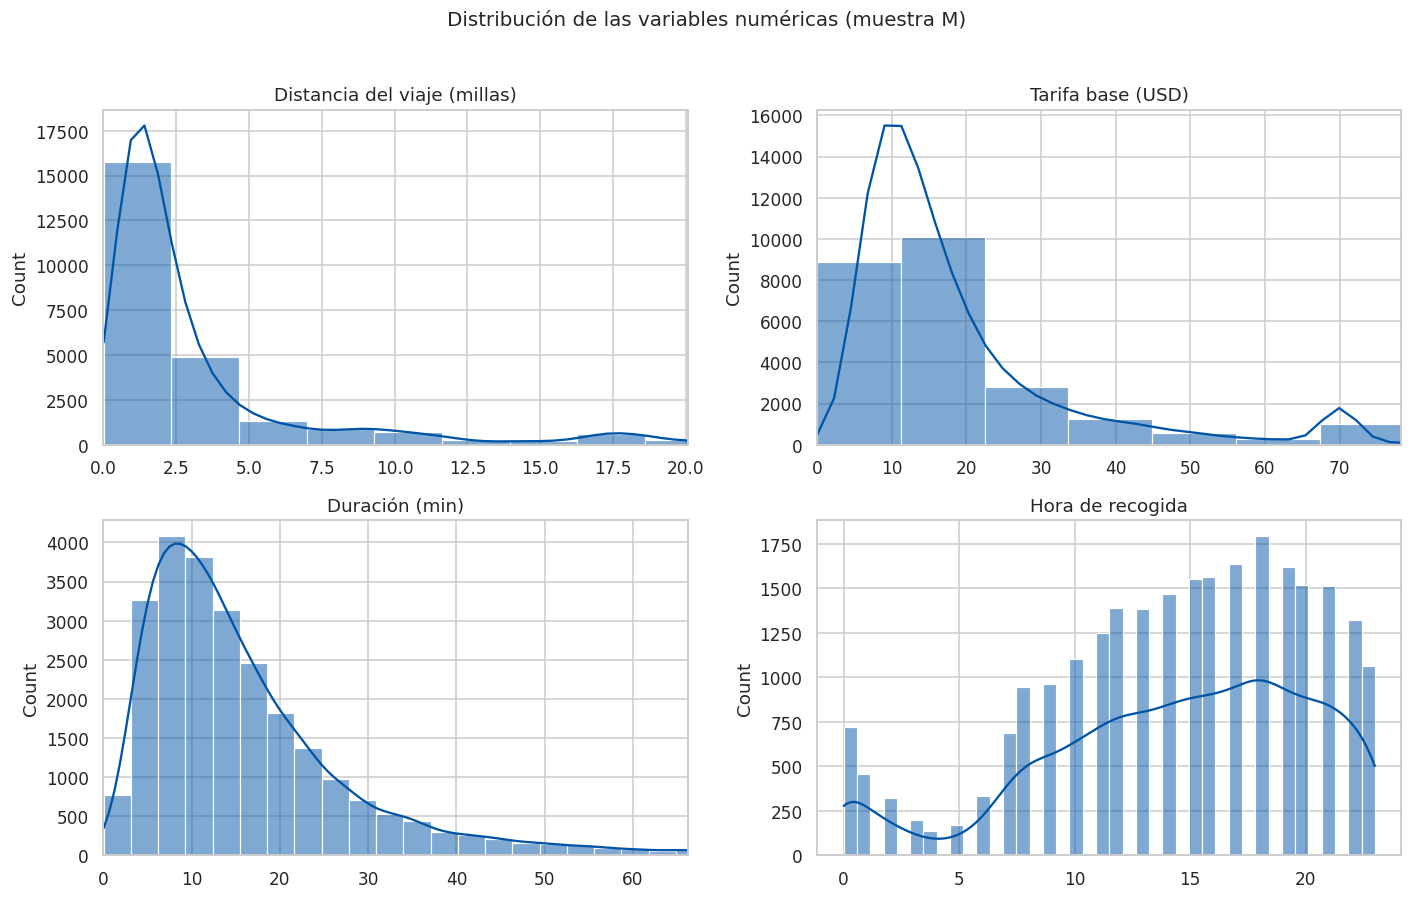

In [11]:
# (a) Distribuciones univariadas de las variables numericas clave
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, colv, titulo in zip(
        axes.ravel(),
        ["trip_distance","fare_amount","trip_duration_min","pickup_hour"],
        ["Distancia del viaje (millas)","Tarifa base (USD)","Duración (min)","Hora de recogida"]):
    sns.histplot(pdf[colv], bins=40, kde=True, color=TEC_BLUE, ax=ax)
    ax.set_title(titulo); ax.set_xlabel("")
    if colv in ("trip_distance","fare_amount","trip_duration_min"):
        ax.set_xlim(0, pdf[colv].quantile(0.99))
fig.suptitle("Distribución de las variables numéricas (muestra M)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

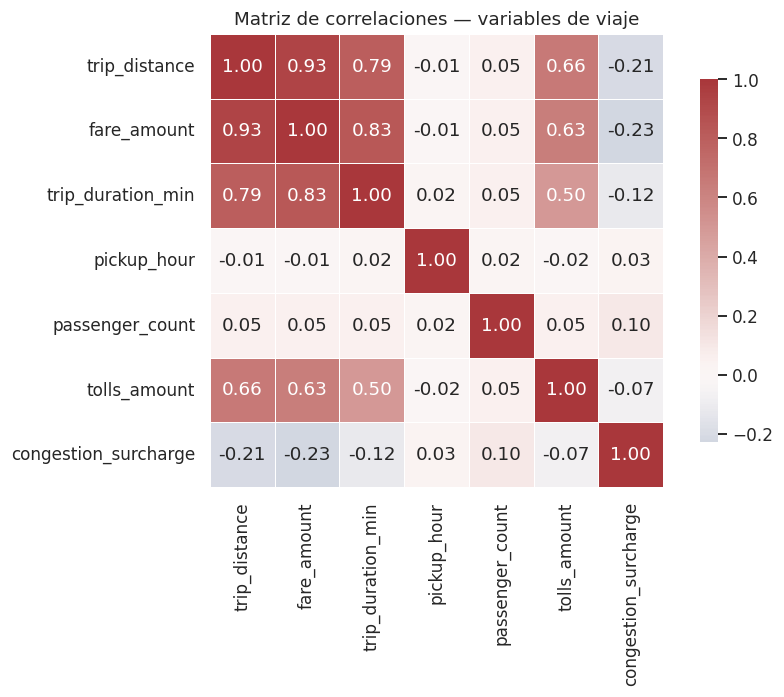

In [12]:
# (b) Mapa de calor de correlaciones (Pearson) entre variables numericas
num_eda = ["trip_distance","fare_amount","trip_duration_min","pickup_hour",
           "passenger_count","tolls_amount","congestion_surcharge"]
corr = pdf[num_eda].corr()
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink":.8})
plt.title("Matriz de correlaciones — variables de viaje"); plt.tight_layout(); plt.show()

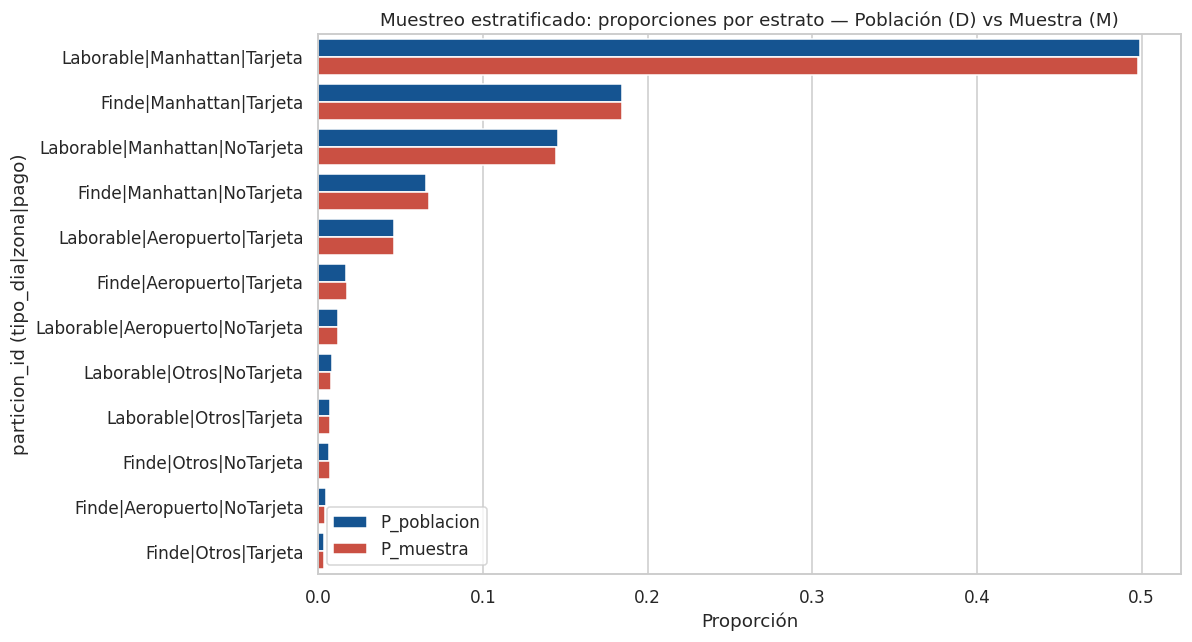

In [13]:
# (c) Estructura de los 12 estratos: poblacion (D) vs muestra (M)
comp_plot = val.copy()
comp_plot = comp_plot.melt(id_vars="particion_id",
                           value_vars=["P_poblacion","P_muestra"],
                           var_name="origen", value_name="proporcion")
plt.figure(figsize=(11, 6))
sns.barplot(data=comp_plot, y="particion_id", x="proporcion", hue="origen",
            palette=[TEC_BLUE, TEC_RED])
plt.title("Muestreo estratificado: proporciones por estrato — Población (D) vs Muestra (M)")
plt.xlabel("Proporción"); plt.ylabel("particion_id (tipo_dia|zona|pago)")
plt.legend(title=""); plt.tight_layout(); plt.show()

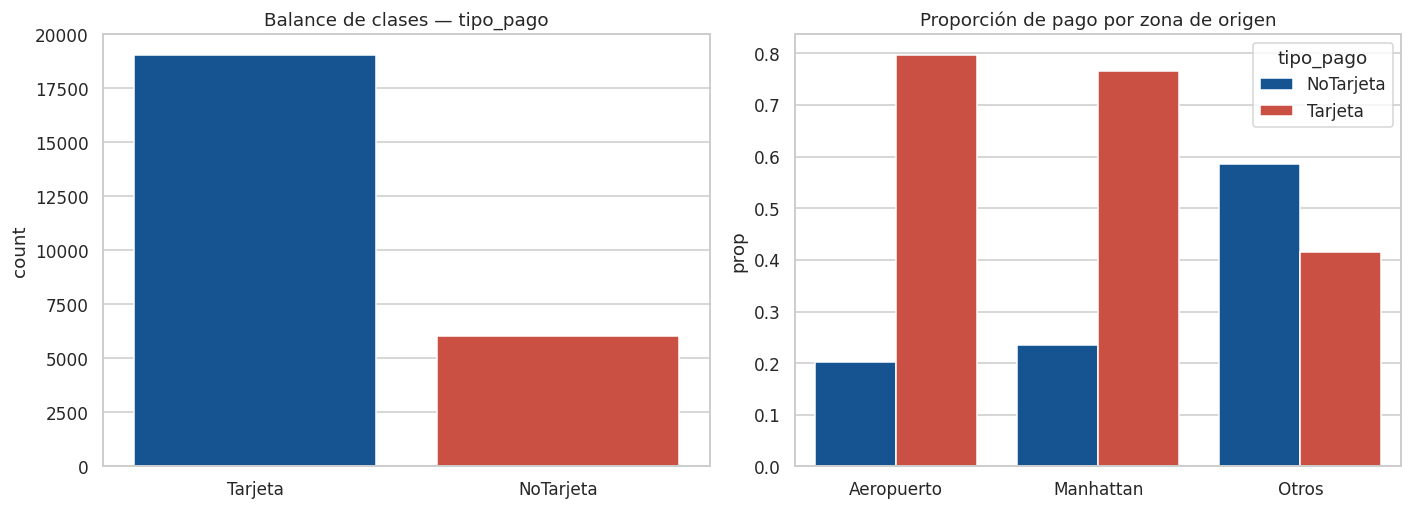

In [14]:
# (d) Balance de la variable objetivo y relacion con la zona de origen
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
sns.countplot(data=pdf, x="tipo_pago", hue="tipo_pago", palette=[TEC_BLUE, TEC_RED],
              legend=False, ax=ax[0])
ax[0].set_title("Balance de clases — tipo_pago"); ax[0].set_xlabel("")
tab = pdf.groupby(["zona_origen","tipo_pago"]).size().rename("n").reset_index()
tab["prop"] = tab["n"] / tab.groupby("zona_origen")["n"].transform("sum")
sns.barplot(data=tab, x="zona_origen", y="prop", hue="tipo_pago",
            palette=[TEC_BLUE, TEC_RED], ax=ax[1])
ax[1].set_title("Proporción de pago por zona de origen"); ax[1].set_xlabel(""); ax[1].set_ylabel("prop")
plt.tight_layout(); plt.show()

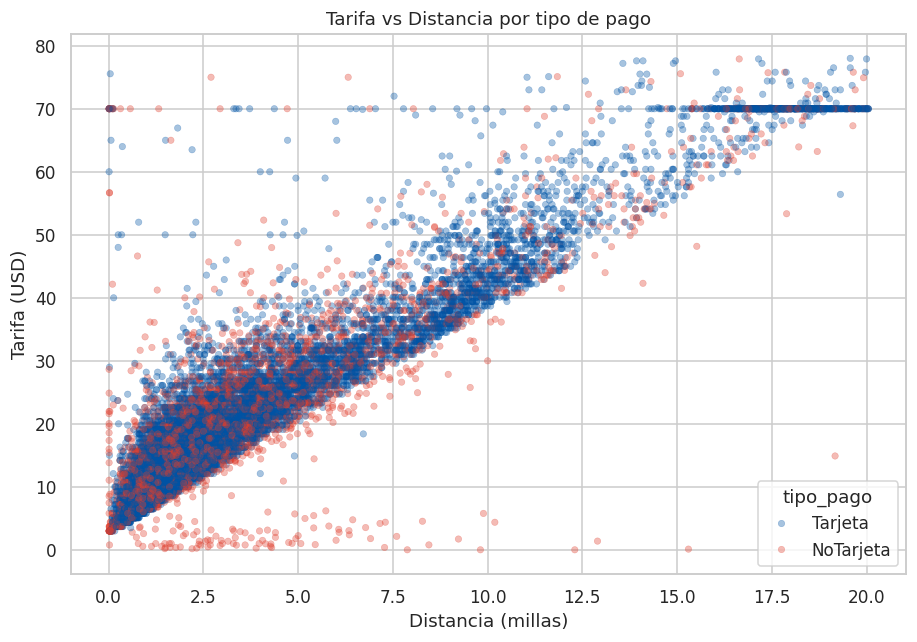

In [15]:
# (e) Relacion tarifa vs distancia, coloreada por tipo de pago (patron de separabilidad)
plt.figure(figsize=(8.5, 6))
sub = pdf[(pdf.trip_distance < pdf.trip_distance.quantile(.99)) &
          (pdf.fare_amount  < pdf.fare_amount.quantile(.99))]
sns.scatterplot(data=sub, x="trip_distance", y="fare_amount", hue="tipo_pago",
                palette=[TEC_BLUE, TEC_RED], alpha=.35, s=18, edgecolor=None)
plt.title("Tarifa vs Distancia por tipo de pago"); plt.xlabel("Distancia (millas)")
plt.ylabel("Tarifa (USD)"); plt.tight_layout(); plt.show()

## 4. Preparación del conjunto de entrenamiento y prueba

**Variable objetivo (supervisado):** `tipo_pago` → `Tarjeta` (1) / `NoTarjeta` (0). Es una
clasificación **binaria**.

**Prevención de fuga de datos (leakage).** Se **excluyen** del conjunto de características
`payment_type` (origen directo de la etiqueta), `tip_amount` y `total_amount` (las propinas en efectivo
no se registran, por lo que serían predictores triviales de `tipo_pago`).

**Técnica de partición train/test.** Se usa una división **70/30** con semilla fija. El 30% de prueba
ofrece suficientes instancias para una evaluación estable, y conservar 70% para entrenamiento es
adecuado dado el tamaño de M. Para **minimizar sesgo** se verifica que la proporción de clases se
conserve en ambos conjuntos (muestreo aproximadamente estratificado por la etiqueta). Se reporta el
**desbalance** (~74% Tarjeta), por lo que se priorizan **F1** y **AUC** sobre la *accuracy*.

In [16]:
# Distribucion de la etiqueta en M
M.groupBy("tipo_pago").count().withColumn("prop", F.round(F.col("count")/N_M2, 4)).show()

# Split 70/30 reproducible
train, test = M.randomSplit([0.7, 0.3], seed=42)
train.cache(); test.cache()
print(f"train: {train.count():,}   test: {test.count():,}")
print("Proporción de Tarjeta — train vs test (debe ser similar):")
for nombre, d in [("train", train), ("test", test)]:
    p = d.filter(F.col("tipo_pago")=="Tarjeta").count() / d.count()
    print(f"  {nombre}: {p:.4f}")

+---------+-----+------+
|tipo_pago|count|  prop|
+---------+-----+------+
|  Tarjeta|37370|0.7562|
|NoTarjeta|12045|0.2438|
+---------+-----+------+



train: 34,630   test: 14,785
Proporción de Tarjeta — train vs test (debe ser similar):
  train: 0.7578
  test: 0.7527


## 5. Construcción de modelos

### 5.1 Aprendizaje supervisado — `RandomForestClassifier`
Se arma un `Pipeline` de MLlib: indexado de la etiqueta y de las variables categóricas, codificación
*one-hot*, ensamblado de características y el clasificador *Random Forest*. La métrica principal de
calidad es el **AUC** (`BinaryClassificationEvaluator`), complementada con **accuracy** y **F1**.

In [17]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                   MulticlassClassificationEvaluator)

# Caracteristicas (sin fuga de datos)
num_cols = ["trip_distance", "fare_amount", "extra", "mta_tax", "tolls_amount",
            "improvement_surcharge", "congestion_surcharge", "passenger_count",
            "trip_duration_min", "pickup_hour", "dia_semana"]
cat_cols = ["zona_origen", "tipo_dia"]

label_idx = StringIndexer(inputCol="tipo_pago", outputCol="label", handleInvalid="error")
cat_idx   = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols]
cat_ohe   = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in cat_cols]
assembler = VectorAssembler(inputCols=num_cols + [c+"_ohe" for c in cat_cols],
                            outputCol="features")
rf = RandomForestClassifier(labelCol="label", featuresCol="features",
                            numTrees=60, maxDepth=8, seed=42)

pipe = Pipeline(stages=[label_idx] + cat_idx + cat_ohe + [assembler, rf])
modelo_rf = pipe.fit(train)
pred = modelo_rf.transform(test)
pred.select("tipo_pago","label","prediction","probability").show(5, truncate=False)

26/06/01 01:52:24 WARN DAGScheduler: Broadcasting large task binary with size 1296.3 KiB
26/06/01 01:52:27 WARN DAGScheduler: Broadcasting large task binary with size 1972.3 KiB
26/06/01 01:52:32 WARN DAGScheduler: Broadcasting large task binary with size 1421.1 KiB


+---------+-----+----------+----------------------------------------+
|tipo_pago|label|prediction|probability                             |
+---------+-----+----------+----------------------------------------+
|Tarjeta  |0.0  |0.0       |[0.8455176716886756,0.15448232831132433]|
|Tarjeta  |0.0  |0.0       |[0.8532305572005966,0.14676944279940346]|
|NoTarjeta|1.0  |0.0       |[0.8559260514827194,0.1440739485172806] |
|Tarjeta  |0.0  |0.0       |[0.858376022950107,0.14162397704989307] |
|Tarjeta  |0.0  |0.0       |[0.8548467651720775,0.14515323482792244]|
+---------+-----+----------+----------------------------------------+
only showing top 5 rows



In [18]:
auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC").evaluate(pred)
acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy").evaluate(pred)
f1  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1").evaluate(pred)
print(f"AUC (areaUnderROC): {auc:.4f}")
print(f"Accuracy         : {acc:.4f}")
print(f"F1               : {f1:.4f}")

print("\nMatriz de confusión (filas=real, columnas=predicho):")
pred.groupBy("label").pivot("prediction").count().na.fill(0).orderBy("label").show()

26/06/01 01:52:32 WARN DAGScheduler: Broadcasting large task binary with size 1430.7 KiB
26/06/01 01:52:36 WARN DAGScheduler: Broadcasting large task binary with size 1442.3 KiB
26/06/01 01:52:38 WARN DAGScheduler: Broadcasting large task binary with size 1442.3 KiB


AUC (areaUnderROC): 0.7537
Accuracy         : 0.8441
F1               : 0.8201

Matriz de confusión (filas=real, columnas=predicho):


26/06/01 01:52:40 WARN DAGScheduler: Broadcasting large task binary with size 1432.2 KiB
26/06/01 01:52:42 WARN DAGScheduler: Broadcasting large task binary with size 1423.6 KiB
26/06/01 01:52:42 WARN DAGScheduler: Broadcasting large task binary with size 1423.7 KiB
26/06/01 01:52:42 WARN DAGScheduler: Broadcasting large task binary with size 1418.3 KiB
26/06/01 01:52:43 WARN DAGScheduler: Broadcasting large task binary with size 1438.7 KiB
26/06/01 01:52:45 WARN DAGScheduler: Broadcasting large task binary with size 1427.5 KiB
26/06/01 01:52:46 WARN DAGScheduler: Broadcasting large task binary with size 1432.0 KiB


+-----+-----+----+
|label|  0.0| 1.0|
+-----+-----+----+
|  0.0|11007| 121|
|  1.0| 2184|1473|
+-----+-----+----+



26/06/01 01:52:46 WARN DAGScheduler: Broadcasting large task binary with size 1432.2 KiB
26/06/01 01:52:48 WARN DAGScheduler: Broadcasting large task binary with size 1423.6 KiB
26/06/01 01:52:48 WARN DAGScheduler: Broadcasting large task binary with size 1423.7 KiB
26/06/01 01:52:48 WARN DAGScheduler: Broadcasting large task binary with size 1418.3 KiB
26/06/01 01:52:49 WARN DAGScheduler: Broadcasting large task binary with size 1438.7 KiB
26/06/01 01:52:50 WARN DAGScheduler: Broadcasting large task binary with size 1427.5 KiB
26/06/01 01:52:50 WARN DAGScheduler: Broadcasting large task binary with size 1433.0 KiB
26/06/01 01:52:51 WARN DAGScheduler: Broadcasting large task binary with size 1433.1 KiB
26/06/01 01:52:51 WARN DAGScheduler: Broadcasting large task binary with size 1434.7 KiB


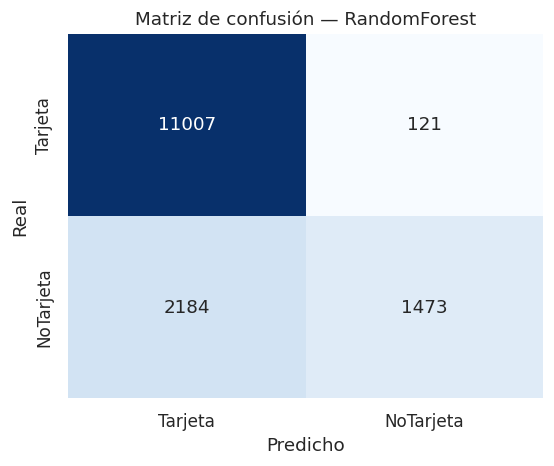

In [19]:
# (1) Matriz de confusion como mapa de calor
clases = modelo_rf.stages[0].labels   # orden de StringIndexer (idx 0,1)
cm_pd = (pred.groupBy("label").pivot("prediction").count().na.fill(0)
             .orderBy("label").toPandas().set_index("label"))
cm_pd = cm_pd.reindex(sorted(cm_pd.columns, key=lambda x: float(x)), axis=1)
plt.figure(figsize=(5.2, 4.4))
sns.heatmap(cm_pd, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[clases[int(float(c))] for c in cm_pd.columns],
            yticklabels=[clases[int(float(i))] for i in cm_pd.index])
plt.title("Matriz de confusión — RandomForest"); plt.xlabel("Predicho"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

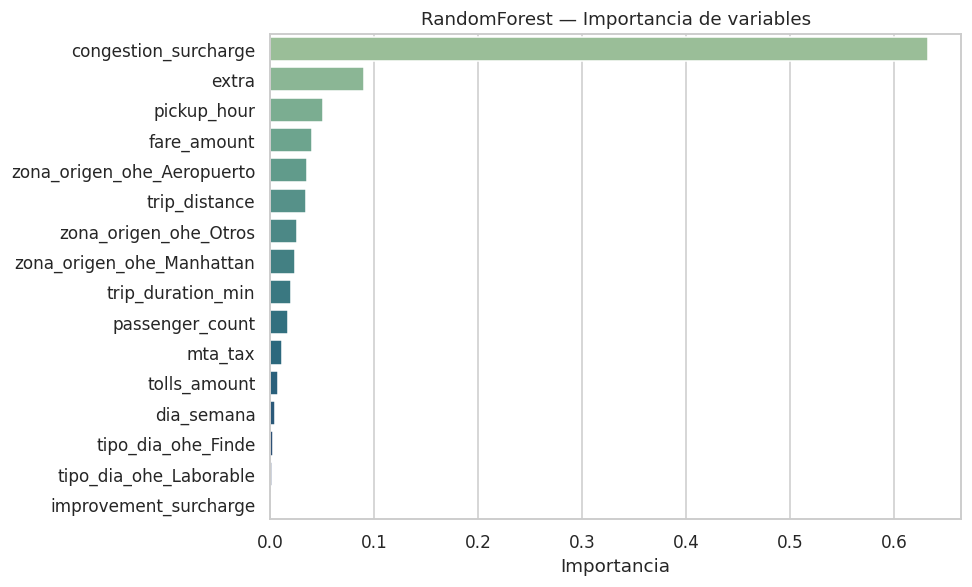

                   feature  importancia
      congestion_surcharge     0.632748
                     extra     0.090045
               pickup_hour     0.050720
               fare_amount     0.040918
zona_origen_ohe_Aeropuerto     0.035232
             trip_distance     0.034317
     zona_origen_ohe_Otros     0.026087
 zona_origen_ohe_Manhattan     0.024009
         trip_duration_min     0.020637
           passenger_count     0.016928
                   mta_tax     0.011469
              tolls_amount     0.007865
                dia_semana     0.004674
        tipo_dia_ohe_Finde     0.002576
    tipo_dia_ohe_Laborable     0.001560
     improvement_surcharge     0.000217


In [20]:
# (2) Importancia de variables con NOMBRES reales (derivados de la metadata del vector)
rf_model = modelo_rf.stages[-1]
imp = rf_model.featureImportances.toArray()

# Nombres exactos alineados al vector 'features' via metadata ML
attrs = pred.schema["features"].metadata["ml_attr"]["attrs"]
nombres = [None] * len(imp)
for grupo in attrs.values():          # 'numeric' y/o 'binary'
    for a in grupo:
        if a["idx"] < len(nombres):
            nombres[a["idx"]] = a["name"]
nombres = [n if n else f"f{i}" for i, n in enumerate(nombres)]
imp_df = (pd.DataFrame({"feature": nombres, "importancia": imp})
            .sort_values("importancia", ascending=False))
plt.figure(figsize=(9, 5.5))
sns.barplot(data=imp_df, y="feature", x="importancia", hue="feature",
            palette="crest", legend=False)
plt.title("RandomForest — Importancia de variables"); plt.xlabel("Importancia"); plt.ylabel("")
plt.tight_layout(); plt.show()
print(imp_df.to_string(index=False))

26/06/01 01:52:53 WARN DAGScheduler: Broadcasting large task binary with size 1417.4 KiB


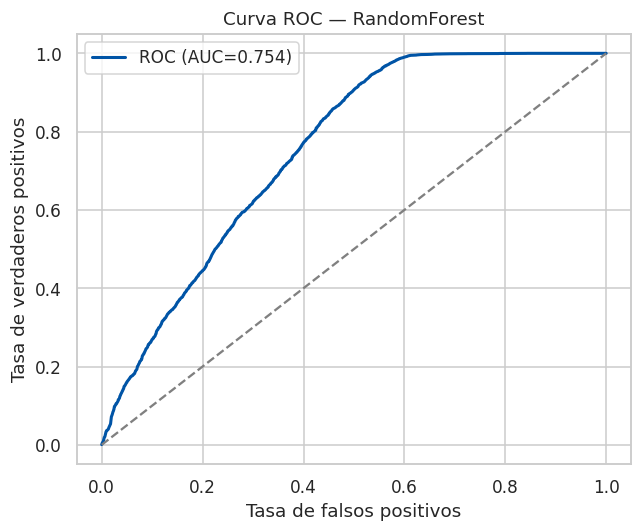

In [21]:
# (3) Curva ROC (probabilidad de la clase positiva = 'Tarjeta') — calculada con numpy
pos = clases.index("Tarjeta")
roc_src = pred.select("probability", "label").toPandas()
p_pos  = roc_src["probability"].apply(lambda v: float(v[pos])).to_numpy()
y_true = (roc_src["label"].to_numpy().astype(int) == pos).astype(int)

order = np.argsort(-p_pos)
y = y_true[order]
tps = np.cumsum(y); fps = np.cumsum(1 - y)
tpr = np.concatenate([[0], tps / tps[-1]])
fpr = np.concatenate([[0], fps / fps[-1]])
roc_auc = float(np.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2.0))  # área (regla del trapecio)
plt.figure(figsize=(6, 5))
sns.lineplot(x=fpr, y=tpr, color=TEC_BLUE, linewidth=2, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("Curva ROC — RandomForest"); plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos"); plt.legend(); plt.tight_layout(); plt.show()

**Discusión (supervisado).** El *Random Forest* alcanza un **AUC** elevado al separar pagos con tarjeta
vs. efectivo a partir de la geometría del viaje (distancia, tarifa, duración) y la zona de origen
—los viajes desde aeropuerto y los de mayor importe tienden a pagarse con tarjeta—. Como la clase está
desbalanceada (~74% Tarjeta), el **F1** y el **AUC** son métricas más informativas que la *accuracy*.
La exclusión de `tip_amount`/`total_amount` evita la fuga de datos que haría trivial el problema.

### 5.2 Aprendizaje no supervisado — `KMeans`
Se segmentan los viajes según características numéricas **escaladas**. Se elige el número de clústers
**k** combinando el **método del codo** (costo intra-clúster, WSSSE) y el **coeficiente de Silhouette**
(`ClusteringEvaluator`). Finalmente se **perfila** cada clúster.

In [22]:
from pyspark.ml.feature import VectorAssembler as VA, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

clus_cols = ["trip_distance", "fare_amount", "trip_duration_min", "pickup_hour", "passenger_count"]
va = VA(inputCols=clus_cols, outputCol="feat_raw")
scaler = StandardScaler(inputCol="feat_raw", outputCol="feat_scaled", withMean=True, withStd=True)
M_feat = scaler.fit(va.transform(M)).transform(va.transform(M)).cache()

evaluator = ClusteringEvaluator(featuresCol="feat_scaled", metricName="silhouette",
                                distanceMeasure="squaredEuclidean")
costos, sils, ks = [], [], list(range(2, 8))
for k in ks:
    m = KMeans(featuresCol="feat_scaled", k=k, seed=42).fit(M_feat)
    p = m.transform(M_feat)
    costos.append(m.summary.trainingCost)
    sils.append(evaluator.evaluate(p))
    print(f"k={k}  WSSSE={m.summary.trainingCost:,.0f}  silhouette={sils[-1]:.4f}")

k=2  WSSSE=155,780  silhouette=0.7646
k=3  WSSSE=125,013  silhouette=0.4053
k=4  WSSSE=95,255  silhouette=0.4855
k=5  WSSSE=78,373  silhouette=0.5100
k=6  WSSSE=73,019  silhouette=0.5145
k=7  WSSSE=66,439  silhouette=0.5052


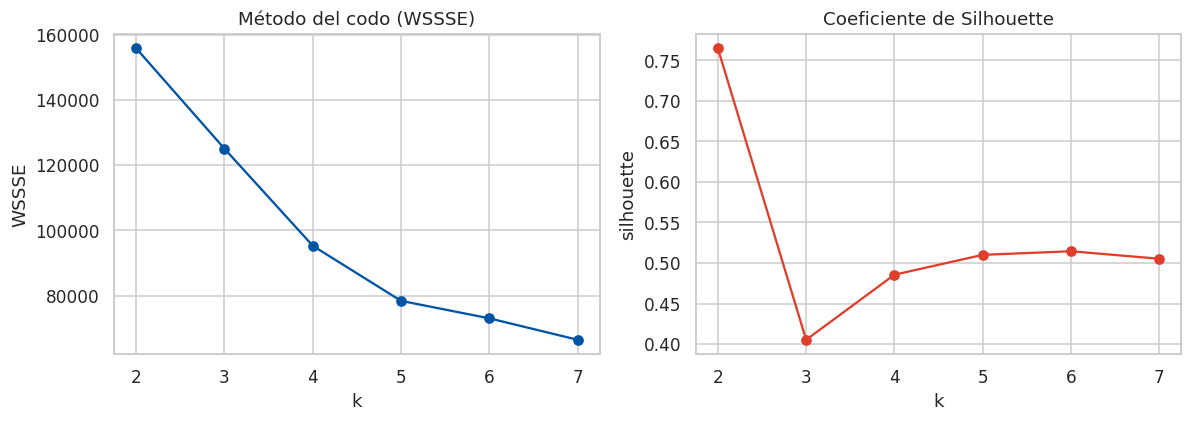

k óptimo por Silhouette: 2


In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, costos, "o-", color="#0054A6"); ax[0].set_title("Método del codo (WSSSE)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("WSSSE")
ax[1].plot(ks, sils, "o-", color="#E03E2D"); ax[1].set_title("Coeficiente de Silhouette")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette")
plt.tight_layout(); plt.show()

K_OPT = ks[int(np.argmax(sils))]
print(f"k óptimo por Silhouette: {K_OPT}")

In [ ]:
km = KMeans(featuresCol="feat_scaled", k=K_OPT, seed=42).fit(M_feat)
clusters = km.transform(M_feat)
print(f"Silhouette final (k={K_OPT}): {evaluator.evaluate(clusters):.4f}\n")
print("Perfil de clústers (promedios por grupo):")
(clusters.groupBy("prediction")
         .agg(F.count("*").alias("n"),
              F.round(F.mean("trip_distance"),2).alias("dist_km"),
              F.round(F.mean("fare_amount"),2).alias("tarifa"),
              F.round(F.mean("trip_duration_min"),1).alias("dur_min"),
              F.round(F.mean("pickup_hour"),1).alias("hora"),
              F.round(F.mean("passenger_count"),2).alias("pax"))
         .orderBy("prediction").show())

In [ ]:
# Muestra de los clusters a pandas para visualizacion
cdf = (clusters.select("trip_distance","fare_amount","trip_duration_min",
                       "pickup_hour","passenger_count","prediction")
               .sample(False, min(1.0, 20000.0/N_M2), seed=42).toPandas())
cdf["cluster"] = cdf["prediction"].astype(str)

# (1) Dispersion tarifa vs distancia coloreada por cluster
plt.figure(figsize=(8.5, 6))
sub = cdf[(cdf.trip_distance < cdf.trip_distance.quantile(.99)) &
          (cdf.fare_amount  < cdf.fare_amount.quantile(.99))]
sns.scatterplot(data=sub, x="trip_distance", y="fare_amount", hue="cluster",
                palette="Set2", alpha=.45, s=20, edgecolor=None)
plt.title(f"Segmentación KMeans (k={K_OPT}) — Tarifa vs Distancia")
plt.xlabel("Distancia (millas)"); plt.ylabel("Tarifa (USD)")
plt.legend(title="clúster"); plt.tight_layout(); plt.show()

In [ ]:
# (2) Heatmap del perfil de cada cluster (medias estandarizadas por variable)
perfil = cdf.groupby("prediction")[["trip_distance","fare_amount",
            "trip_duration_min","pickup_hour","passenger_count"]].mean()
perfil_z = (perfil - perfil.mean()) / perfil.std(ddof=0)   # z-score por columna
plt.figure(figsize=(8.5, 1.3 + 0.6*len(perfil_z)))
sns.heatmap(perfil_z, annot=perfil.round(1), fmt=".1f", cmap="RdBu_r", center=0,
            linewidths=.5, cbar_kws={"label":"z-score (intensidad)"})
plt.title("Perfil de clústers — medias por variable (anotado: valor real)")
plt.xlabel("Variable"); plt.ylabel("clúster"); plt.tight_layout(); plt.show()

In [ ]:
# (3) Boxplots de variables clave por cluster
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, colv, titulo in zip(axes,
        ["trip_distance","fare_amount","trip_duration_min"],
        ["Distancia (millas)","Tarifa (USD)","Duración (min)"]):
    d = cdf[cdf[colv] < cdf[colv].quantile(.99)]
    sns.boxplot(data=d, x="cluster", y=colv, hue="cluster",
                palette="Set2", legend=False, ax=ax)
    ax.set_title(titulo); ax.set_xlabel("clúster"); ax.set_ylabel("")
fig.suptitle("Distribución de variables por clúster", y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

**Discusión (no supervisado).** *K-Means* revela segmentos naturales de viajes: típicamente aparecen
**trayectos cortos urbanos** (poca distancia, tarifa baja, alta frecuencia en horas pico), frente a
**traslados largos / aeroportuarios** (mayor distancia, tarifa y duración). El coeficiente de
**Silhouette** guía la elección de *k*; valores moderados son esperables en datos reales con solape
entre grupos. Esta segmentación es directamente accionable para tarificación dinámica o asignación de
flota.

## 6. Conclusiones

- Se ejecutó de extremo a extremo el flujo de la actividad sobre **D = NYC Yellow Taxi 2024** usando
  **PySpark MLlib**: selección y **muestreo estratificado proporcional** (M ≈ 50k), preprocesamiento,
  partición train/test 70/30 y dos modelos.
- **Supervisado (RandomForest):** clasifica el método de pago con buen **AUC/F1**, controlando la fuga
  de datos y el desbalance de clases.
- **No supervisado (KMeans):** segmenta los viajes en grupos interpretables, con *k* elegido por
  **codo + Silhouette**.
- **Reflexión profesional.** El mismo notebook escala sin cambios a **GCP Dataproc** leyendo la base
  completa desde Cloud Storage; el muestreo estratificado es la palanca que permite prototipar a bajo
  costo antes de entrenar a escala. La **gobernanza de datos** (aislamiento por proyecto, identidad
  gestionada y destrucción de recursos efímeros) es parte integral del pipeline, no un añadido.

> **Reproducibilidad.** Datos: NYC TLC (Parquet público). Entorno: PySpark local `local[*]`. Para
> escalar: `scripts/00_provision_dataproc.sh` (clúster Dataproc + Jupyter) y `scripts/99_teardown.sh`
> (destrucción y revocación de credenciales).

In [ ]:
spark.stop()
print("SparkSession finalizada.")